# 06 — Model Evaluation & Draw Class Analysis

This notebook compares the baseline classifiers (Logistic Regression, Random Forest, XGBoost) and performs an in-depth analysis on the Draw class prediction performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, 
    log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

## Load Data and Pre-match Features

In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

feature_cols = [
    'HomeForm', 'AwayForm', 'HomeGoalsAvg5', 'AwayGoalsAvg5',
    'HomeGoalsConcededAvg5', 'AwayGoalsConcededAvg5', 'HomeWinRate5', 'AwayWinRate5',
    'HomeH2HForm5', 'HomePosition', 'AwayPosition', 'HomeGoalDiff5', 'AwayGoalDiff5',
    'HomeRestDays', 'AwayRestDays'
]

X_train = train_df[feature_cols]
y_train = train_df['FullTimeResult']
X_test = test_df[feature_cols]
y_test = test_df['FullTimeResult']

## Train Baseline Models

In [3]:
# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)

# XGBoost
class_map = {'A': 0, 'D': 1, 'H': 2}
inv_class_map = {0: 'A', 1: 'D', 2: 'H'}
y_train_num = y_train.map(class_map)
y_test_num = y_test.map(class_map)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_num)
xgb_pred_num = xgb_model.predict(X_test)
xgb_pred = pd.Series(xgb_pred_num).map(inv_class_map)
xgb_prob = xgb_model.predict_proba(X_test)

## Unified Model Comparison Table

In [4]:
def evaluate_model(y_true, y_pred, y_prob, name):
    acc = accuracy_score(y_true, y_pred)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    _, _, weighted_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    loss = log_loss(y_true, y_prob, labels=np.unique(y_true))
    return {
        'Model': name,
        'Accuracy': acc,
        'Macro Precision': macro_prec,
        'Macro Recall': macro_rec,
        'Macro F1': macro_f1,
        'Weighted F1': weighted_f1,
        'Log Loss': loss
    }

comparison_data = [
    evaluate_model(y_test, lr_pred, lr_prob, 'Logistic Regression'),
    evaluate_model(y_test, rf_pred, rf_prob, 'Random Forest'),
    evaluate_model(y_test, xgb_pred, xgb_prob, 'XGBoost')
]
comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Log Loss
0,Logistic Regression,0.540061,0.495098,0.451315,0.397651,0.465618,0.991527
1,Random Forest,0.498471,0.419383,0.423921,0.399527,0.454114,1.022892
2,XGBoost,0.478287,0.421504,0.418798,0.408792,0.452748,1.081590


## Plot Confusion Matrices

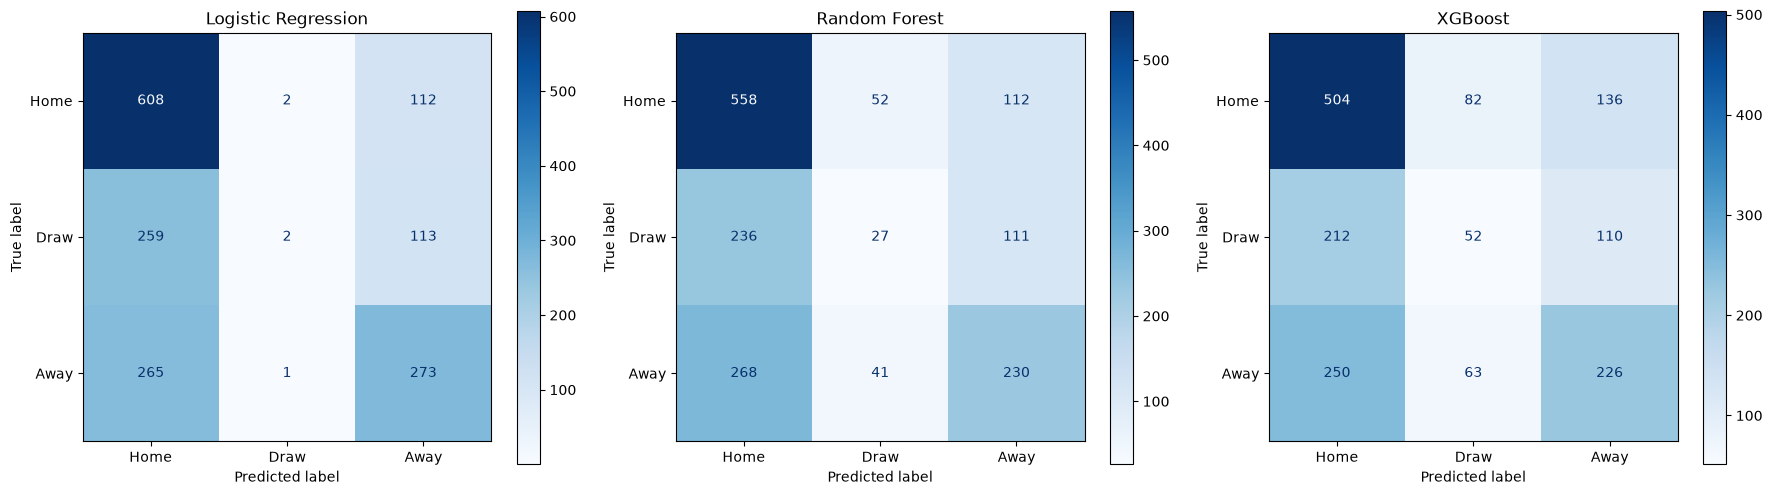

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    (lr_pred, 'Logistic Regression'),
    (rf_pred, 'Random Forest'),
    (xgb_pred, 'XGBoost')
]

for ax, (preds, name) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds, labels=['H', 'D', 'A'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Home', 'Draw', 'Away'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../docs/baseline_confusion_matrices.png')
plt.show()

## Draw Class Analysis & Experiments

As observed, the baseline classifiers struggle to predict Draws. Let's try to adjust class weights and thresholds to see if we can improve Draw class recall.

### Experiment A: Class Weight Balancing in Logistic Regression and Random Forest

In [6]:
# Logistic Regression with balanced class weights
lr_weighted = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
lr_weighted.fit(X_train, y_train)
lr_w_pred = lr_weighted.predict(X_test)
print('=== Logistic Regression (Balanced Weights) ===')
print(classification_report(y_test, lr_w_pred))

# Random Forest with balanced class weights
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_weighted.fit(X_train, y_train)
rf_w_pred = rf_weighted.predict(X_test)
print('=== Random Forest (Balanced Weights) ===')
print(classification_report(y_test, rf_w_pred))

=== Logistic Regression (Balanced Weights) ===
              precision    recall  f1-score   support

           A       0.49      0.60      0.54       539
           D       0.24      0.17      0.20       374
           H       0.59      0.58      0.58       722

    accuracy                           0.49      1635
   macro avg       0.44      0.45      0.44      1635
weighted avg       0.48      0.49      0.48      1635



=== Random Forest (Balanced Weights) ===
              precision    recall  f1-score   support

           A       0.48      0.51      0.49       539
           D       0.22      0.16      0.18       374
           H       0.55      0.61      0.58       722

    accuracy                           0.47      1635
   macro avg       0.42      0.42      0.42      1635
weighted avg       0.45      0.47      0.46      1635



### Experiment B: Probability Threshold Tuning for Draw

By default, the model predicts the class with the highest probability. Since Draws have a lower prior (~24.6%), their predicted probability rarely exceeds Home/Away. Let's adjust the threshold for the Draw class using the Logistic Regression baseline probabilities.

In [7]:
# Using Logistic Regression probability output
# lr_prob columns: 0=A, 1=D, 2=H
draw_probs = lr_prob[:, 1]

for threshold in [0.20, 0.25, 0.28, 0.30, 0.35]:
    tuned_preds = []
    for idx, prob in enumerate(lr_prob):
        # If Draw probability exceeds threshold, predict Draw, else predict highest of A or H
        if prob[1] >= threshold:
            tuned_preds.append('D')
        else:
            tuned_preds.append('H' if prob[2] >= prob[0] else 'A')
    
    print(f'\nThreshold for Draw: {threshold}')
    print(f'Draw Recall: {precision_recall_fscore_support(y_test, tuned_preds, average=None)[1][1]:.4f}')
    print(f'Macro F1: {precision_recall_fscore_support(y_test, tuned_preds, average="macro")[2]:.4f}')


Threshold for Draw: 0.2
Draw Recall: 0.9412
Macro F1: 0.2095

Threshold for Draw: 0.25
Draw Recall: 0.5909
Macro F1: 0.3925

Threshold for Draw: 0.28
Draw Recall: 0.1872
Macro F1: 0.4277

Threshold for Draw: 0.3
Draw Recall: 0.0401
Macro F1: 0.4051

Threshold for Draw: 0.35
Draw Recall: 0.0053
Macro F1: 0.3972
